# 03 - Machine Learning Modeling

### Credit Card Fraud Risk Detection & Transaction Risk Scoring

**Author: Corbin Couger**

Objective - Build, Train, and Evaluate two machine learning models to determine best suited model in predicting fraud.

Dataset - [Kaggle Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---

Outline:

1. Load Preprocessed Datasets
2. Build XGBoost Classification Model
3. Keras Neural Network Model
4. Model Comparison
5. SHAP Explainablity
6. Save Model

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, classification_report, precision_score, recall_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import shap
import json

PROCESSED_PATH = '../data/processed/'


### 1. Load Preprocessed Data

In [3]:
X_train = pd.read_csv(f'{PROCESSED_PATH}X_train.csv')
X_val = pd.read_csv(f'{PROCESSED_PATH}X_val.csv')
X_test = pd.read_csv(f'{PROCESSED_PATH}X_test.csv')

y_train = pd.read_csv(f'{PROCESSED_PATH}y_train.csv').squeeze()
y_val = pd.read_csv(f'{PROCESSED_PATH}y_val.csv').squeeze()
y_test = pd.read_csv(f'{PROCESSED_PATH}y_test.csv').squeeze()

with open(f'{PROCESSED_PATH}scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

In [5]:
print('--- Shape Check --------------')
print(f'X Train: {X_train.shape}')
print(f'X Val: {X_val.shape}')
print(f'X Test: {X_test.shape}')

--- Shape Check --------------
X Train: (396780, 31)
X Val: (42446, 31)
X Test: (42559, 31)


### 2. XGBoost Classification Model

In [10]:
xgb_model = XGBClassifier(
    n_estimators = 500,
    max_depth = 6,
    learning_rate = .05,
    subsample = .8,
    scale_pos_weigt = 1,
    eval_metric = 'aucpr',
    early_stopping_rounds = 20,
    random_state = 42
)

xgb_model.fit(X_train, y_train, eval_set = [(X_val, y_val)], verbose = 50)

[0]	validation_0-aucpr:0.41876
[50]	validation_0-aucpr:0.71933
[92]	validation_0-aucpr:0.75579


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [11]:
xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1] # will aid in determining the threshold in which to actually predict fraud

xgb_precision, xgb_recall, xgb_thresholds = precision_recall_curve(y_val, xgb_val_probs)
xgb_auc_pr = average_precision_score(y_val, xgb_val_probs)

print(f'XGBoost PR-AUC (validation): {xgb_auc_pr:.4f}')

XGBoost PR-AUC (validation): 0.7694


In [13]:
f1_scores = []
thresholds = []

for thresh in xgb_thresholds:
    preds = (xgb_val_probs >= thresh).astype(int)
    f1_scores.append(f1_score(y_val, preds, zero_division=0))
    thresholds.append(thresh)

xgb_best_thresh = thresholds[np.argmax(f1_scores)]

xgb_best_f1 = max(f1_scores)

print(f'Best Threshold: {xgb_best_thresh}')
print(f'Best F1: {xgb_best_f1}')

Best Threshold: 0.9851922988891602
Best F1: 0.8656716417910447


In [15]:
# using this threshold, I can create predictions:
xgb_val_preds = (xgb_val_probs >= xgb_best_thresh).astype(int)

xgb_cr = classification_report(y_val, xgb_val_preds, target_names=['Legitimate', 'Fraud'])
print(xgb_cr)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42375
       Fraud       0.92      0.82      0.87        71

    accuracy                           1.00     42446
   macro avg       0.96      0.91      0.93     42446
weighted avg       1.00      1.00      1.00     42446



In [31]:
# XGBoost Results
xgb_results = {
    'model'     : 'XGBoost',
    'precision' : precision_score(y_val, xgb_val_preds),
    'recall'    : recall_score(y_val, xgb_val_preds),
    'f1'        : f1_score(y_val, xgb_val_preds),
    'auc_pr'    : xgb_auc_pr,
    'threshold' : xgb_best_thresh
}

print(xgb_results)

{'model': 'XGBoost', 'precision': 0.9206349206349206, 'recall': 0.8169014084507042, 'f1': 0.8656716417910447, 'auc_pr': 0.7694169040079994, 'threshold': np.float32(0.9851923)}


##### **Notes:**

Looking at the classification report, the *XGBoost* model did fairly well at catching fraud within the data.

Utilizing the optimal threshold, this model correctly identifies 82% of fraudulent transactions all while maintaining 92% precision. This model allows fraud teams to only review high-confidence cases with few false positives.

*The Threshold* (.985) is high. The model needs to be 98.5% confident before flagging a fraudulent transaction. This could be due to:
- XGBoost model trained on SMOTE data. Meaning it learns most transactions are legit, keeping it conservative
- This should look different on the Keras model in the next section, will compare the two

### 3. Keras Neural Network

In [18]:
# Reproductibility
tf.random.set_seed(42)
np.random.seed(42)

# In the preprocessing phase I had converted the training, validation, and testing datasets to dataframes & series... Keras wants numpy arrays
X_train_nn = X_train.values.astype('float32')
X_val_nn = X_val.values.astype('float32')
X_test_nn = X_test.values.astype('float32')

y_train_nn = y_train.values.astype('float32')
y_val_nn = y_val.values.astype('float32')
y_test_nn = y_test.values.astype('float32')

In [20]:
nn_model = keras.Sequential([
    # input
    layers.Input(shape = (X_train_nn.shape[1],)),
    # hidden 1
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(.25), # reduce overfitting

    # hidden 2
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(.2),

    # hidden 3
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(.1),

    # Output
    layers.Dense(1, activation='sigmoid') # 1 prediction, sigmoid provides a binary probability output
])

nn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=.001),
    loss = 'binary_crossentropy', # binary output
    metrics = [
        keras.metrics.AUC(curve = 'PR', name = 'auc_pr'), # like the XGBoost, checking precision and recall
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recal')
    ]
)

print(nn_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 224 (896.00 B)

None


To reduce run-time and loss I will introduce early stopping and learning rate reduction to the model when fitting.

In [21]:
early_stop = callbacks.EarlyStopping(
    monitor = 'val_auc_pr',
    patience = 10,
    mode = 'max',
    restore_best_weights = True,
    verbose = 1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor = 'val_auc_pr',
    factor = .5,
    patience = 5,
    mode = 'max',
    verbose = 1
)

In [23]:
# training the model
history = nn_model.fit(
    X_train_nn, y_train_nn,
    validation_data = (X_val_nn, y_val_nn),
    epochs = 100,
    batch_size = 2048, # helps reduce run-time
    callbacks = [early_stop, reduce_lr],
    verbose = 1
)

Epoch 1/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc_pr: 0.9994 - loss: 0.0059 - precision: 0.9977 - recal: 0.9997 - val_auc_pr: 0.6977 - val_loss: 0.0063 - val_precision: 0.6630 - val_recal: 0.8592 - learning_rate: 0.0010
Epoch 2/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc_pr: 0.9996 - loss: 0.0048 - precision: 0.9984 - recal: 0.9997 - val_auc_pr: 0.6912 - val_loss: 0.0061 - val_precision: 0.6932 - val_recal: 0.8592 - learning_rate: 0.0010
Epoch 3/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc_pr: 0.9996 - loss: 0.0045 - precision: 0.9985 - recal: 0.9997 - val_auc_pr: 0.7006 - val_loss: 0.0061 - val_precision: 0.7093 - val_recal: 0.8592 - learning_rate: 0.0010
Epoch 4/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc_pr: 0.9996 - loss: 0.0041 - precision: 0.9986 - recal: 0.9997 - val_auc_pr: 0.7006 - val_loss: 0.0060 - val_precision: 0.7093 - val_recal: 0.8592 - learning_rate: 0.0010
Epoch 5/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc_pr: 0.9996 - loss: 0.0039

Similarly to the XGBoost, I will calculate the best threshold for identifying fraud with the Neural Network model. As mentioned, I assume this to be lower than the XGBoost.

In [25]:
nn_val_probs = nn_model.predict(X_val_nn, verbose = 0).flatten()

nn_precision, nn_recall, nn_thresholds = precision_recall_curve(y_val_nn, nn_val_probs)
nn_auc_pr = average_precision_score(y_val_nn, nn_val_probs)

print(f'Keras NN PR-AUC (validation): {nn_auc_pr}')

Keras NN PR-AUC (validation): 0.8519296781175678


In [26]:
nn_f1_scores = []
nn_thresholds_list = []

for thresh in nn_thresholds:
    preds = (nn_val_probs >= thresh).astype(int)
    nn_f1_scores.append(f1_score(y_val_nn, preds, zero_division=0))
    nn_thresholds_list.append(thresh)

nn_best_thresh = nn_thresholds_list[np.argmax(nn_f1_scores)]
nn_best_f1 = max(nn_f1_scores)

print(f'NN Optimal Threshold: {nn_best_thresh}')
print(f'NN Best F1 at Threshold: {nn_best_f1}')

NN Optimal Threshold: 0.9728171229362488
NN Best F1 at Threshold: 0.8787878787878788


In [27]:
nn_val_preds = (nn_val_probs >= nn_best_thresh).astype(int)

nn_cr = classification_report(y_val_nn, nn_val_preds, target_names=['Legitimate', 'Fraud'])
print(nn_cr)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42375
       Fraud       0.95      0.82      0.88        71

    accuracy                           1.00     42446
   macro avg       0.98      0.91      0.94     42446
weighted avg       1.00      1.00      1.00     42446



In [30]:
# Keras Results
nn_results = {
    'model'     : 'Keras NN',
    'precision' : precision_score(y_val, nn_val_preds),
    'recall'    : recall_score(y_val, nn_val_preds),
    'f1'        : f1_score(y_val, nn_val_preds),
    'auc_pr'    : nn_auc_pr,
    'threshold' : nn_best_thresh
}

print(nn_results)

{'model': 'Keras NN', 'precision': 0.9508196721311475, 'recall': 0.8169014084507042, 'f1': 0.8787878787878788, 'auc_pr': 0.8519296781175678, 'threshold': np.float32(0.9728171)}


##### **Notes:**

The *Keras NN* model performed very well on catching fraudulent transactions. Being 3% more precise than the XGBoost model. In the real-world this can translate to millions of transactions. This neural network does catch the same proportion of actual fraud that the XGBoost model did at 82%. The threshold still did remain high for the Neural Network, but I attribute this to the oversampling technique (SMOTE) that I implemented. This technique is making each of these models flag transactions that they are only **very** certain about.

Now I will create a comparison dataframe to compoare these two models (which I know the NN will be on top)

### 4. Model Comparison

In [32]:
comparison_df = pd.DataFrame([xgb_results, nn_results])
comparison_df = comparison_df.set_index('model')
comparison_df.style.highlight_max(axis=0, color = 'green')

,precision,recall,f1,auc_pr,threshold
model,,,,,
XGBoost,0.920635,0.816901,0.865672,0.769417,0.985192
Keras NN,0.950820,0.816901,0.878788,0.851930,0.972817


##### **Notes:**
The chart above demonstrates the differences between the XGBoost and Keras NN models. Keras NN is winning and/or tied in every category.

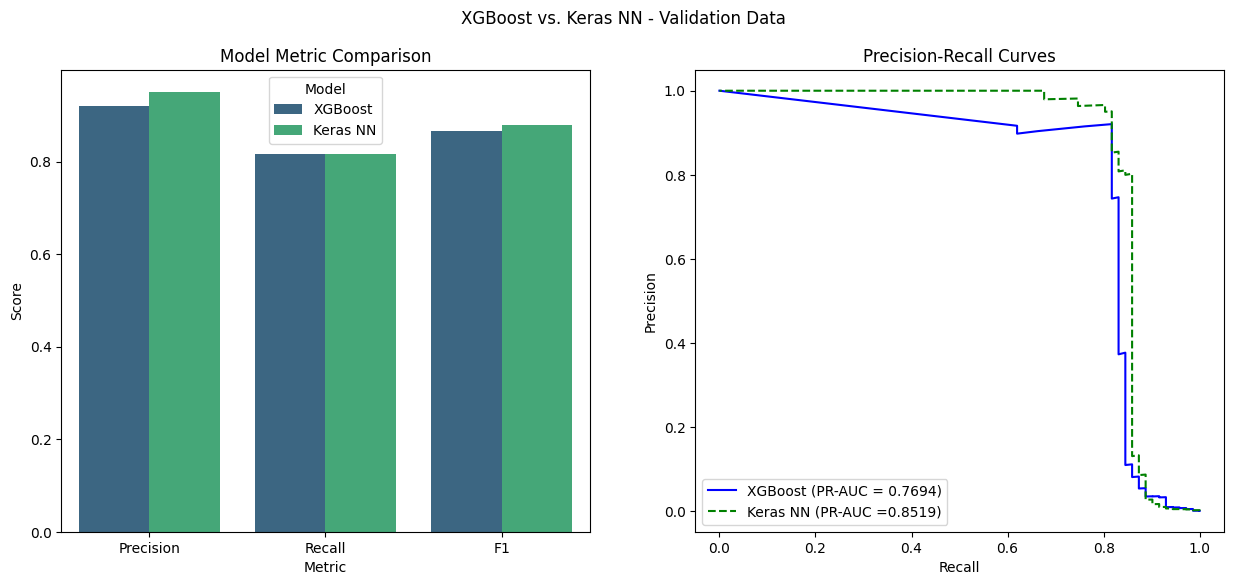

In [44]:
fig, axes = plt.subplots(1, 2, figsize = (15, 6))

metrics = ['Precision', 'Recall', 'F1']
xgb_values = [xgb_results['precision'], xgb_results['recall'], xgb_results['f1']]
nn_values = [nn_results['precision'], nn_results['recall'], nn_results['f1']]

bar_chart_data = pd.DataFrame({
    'Model': ['XGBoost']*3 + ['Keras NN']*3,
    'Metric': metrics*2,
    'Score': xgb_values + nn_values
})

sns.barplot(data = bar_chart_data, x = 'Metric', y = 'Score', hue = 'Model', ax=axes[0], palette = 'viridis')
axes[0].set_title('Model Metric Comparison')

# now the curves
axes[1].plot(xgb_recall, xgb_precision, color = 'blue', label = f'XGBoost (PR-AUC = {xgb_auc_pr:.4f})')
axes[1].plot(nn_recall, nn_precision, color = 'green', linestyle = '--', label = f'Keras NN (PR-AUC ={nn_auc_pr:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

plt.suptitle('XGBoost vs. Keras NN - Validation Data')
plt.savefig('../data/processed/fig_model_comparison.png', dpi=150, bbox_inches='tight')


plt.show()

##### **Notes:**

The above plot demonstrates, visually, how these models vary. The Keras NN performing better in 2 of the three metrics and matching the Recall of the XGBoost Model. On the right plot (Precision-Recall curve), the lines demonstrate how much fraud the model actually captures. The green-dashed line (Keras NN) has higher metrics on each axis, capturing more accurate predictions.

These plots are great and symbolize the importance of comparing the models from a machine learning prespective. Now I will take the results of the Keras NN model and create a *Business Impact* perspective to show the impact of the chosen model.

In [ ]:
avg_fraud_amount = 122.21 # calculated average fraud transaction amount from EDA notebook
total_transactions = 284807 # size of dataset (before SMOTE)
fraud_rate = .00172 # ratio calculated in EDA
estimated_fraud_n = int(total_transactions * fraud_rate)

caught = int(estimated_fraud_n * nn_results['recall']) # this calcualtes the fraudulent transactions the Keras NN would catch
missed = int(estimated_fraud_n - caught) # amount of fraudulent transactions Keras NN missed

flags = int(caught / nn_results['precision']) # false positive rate
false_alarms = flags - caught

print('==== Business Impact (Estimated) ====')
print(f'Estimated fraud transactions: {estimated_fraud_n:,}')
print(f'Caught by model (82% recall): {caught:,}')
print(f'Missed by model: {missed:,}')
print(f'Estimated value caught: {caught * avg_fraud_amount} Euros')
print('=================================')
print(f'Total flags raised: {flags:,}')
print(f'False positives (95% precision): {false_alarms:,}')
print(f'False positive rate: {false_alarms/flags*100:.2f}% of flags')
print('=================================')

==== Business Impact (Estimated) ====
Estimated fraud transactions: 489
Caught by model (82% recall): 399
Missed by model: 90
Estimated value caugt: 48761.79 Euros
Total flags raised: 419
False positives (95% precision): 20
False positive rate: 4.77% of flags


**Further Interpretation**

For every 100 transactions flagged, the Keras NN model predicts 95 of them as genuine fraud and 5 are actually legitimate transactions. This greatly reduces the amount of transactions that a fraud analyst would need to look through. The cherry on top is that this model accurately is catching a large amount of fraudulent transactions and on average is saving nearly 50k Euros for the time period of the dataset.

**My Recommendation**

### **Keras Neural Network Model**

Utilize and deploy the *Keras NN* model for catching fraudulent transactions. The model accurately catches 82% of fraudelent transactions and predicts them to be fraud at an precision of 95%. If there is further accuracy adjustments or the need for finer-tuning, this neural network is adjustable and easily fine-tuned.

### 5. SHAP Explainability

In this section of the notebook, I will take a look at the SHAP explainability. This will help explain why the predictions were made.

Something to note within this section is that I will be generating the explainability using the XGBoost model. This is because these models will give nearly identical patterns since they were trained on the same data. The XGBoost model works much better with SHAP and the run-time will be significantly quicker using the XGBoost.

*More Detail on Using XGBoost for SHAP*
SHAP explainability is computed on the XGBoost model over the Keras NN as a property of SHAP, TreeExplainer, provides me with exact values in seconds rather than minutes to hours. This tradeoff will positively impact the process for which the model is explained based on the data used to build it. Neural Networks tend to be difficult to audit, they have what is called the 'black box' where the reasons for predictions isn't as accessible. Using the explainability of the XGBoost model alongside the Keras NN will be a game changer for interpreting the model's decision making.

I'll say it like this, the XGBoost model explains how to predict fraud and the Keras NN just predicts better.

In [53]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val)

print(f'SHAP Values Shape: {shap_values.shape}')

SHAP Values Shape: (42446, 31)


C:\Users\Coug\AppData\Local\Temp\ipykernel_27780\2697257845.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


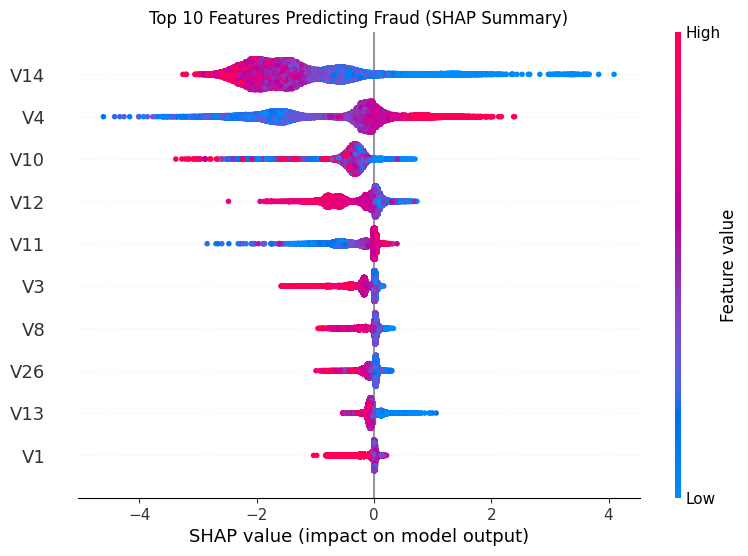

In [56]:
# displaying the top 10 features within the dataset

plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_val,
    plot_type='dot',
    max_display = 10,
    show = False
)

plt.title('Top 10 Features Predicting Fraud (SHAP Summary)')
plt.savefig('../data/processed/fig_shap_summary.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [57]:
# showing how the model made a correct decision using the data
fraud_indices = np.where((y_val.values == 1) & (xgb_val_preds == 1))[0]
sample_idx = fraud_indices[0]

print(f'Transaction Index: {sample_idx}')
print(f'True Label: Fraud')
print(f'Risk Score: {xgb_val_probs[sample_idx]:.4f}')
print(f'Threshold: {xgb_best_thresh:.4f}')
print(f'Model\'s Decision: {'Flagged as Fraud' if xgb_val_probs[sample_idx] >= xgb_best_thresh else 'Approved (Legit)'}')

Transaction Index: 451
True Label: Fraud
Risk Score: 0.9870
Threshold: 0.9852
Model's Decision: Flagged as Fraud


##### **Notes:**

Above, the plot highlights the top 10 features that have the highest predicting power for fraud. Feature V14 has strong predictive power, the lower the value of V14 the stronger the indication of fraud. For V4, the second strongest feature, the higher the value of V4 the higher likelihood of fraud.

Below the plot in the output, I have highlighted one of the correct decisions the model made and the risk the model associated with that transaction.

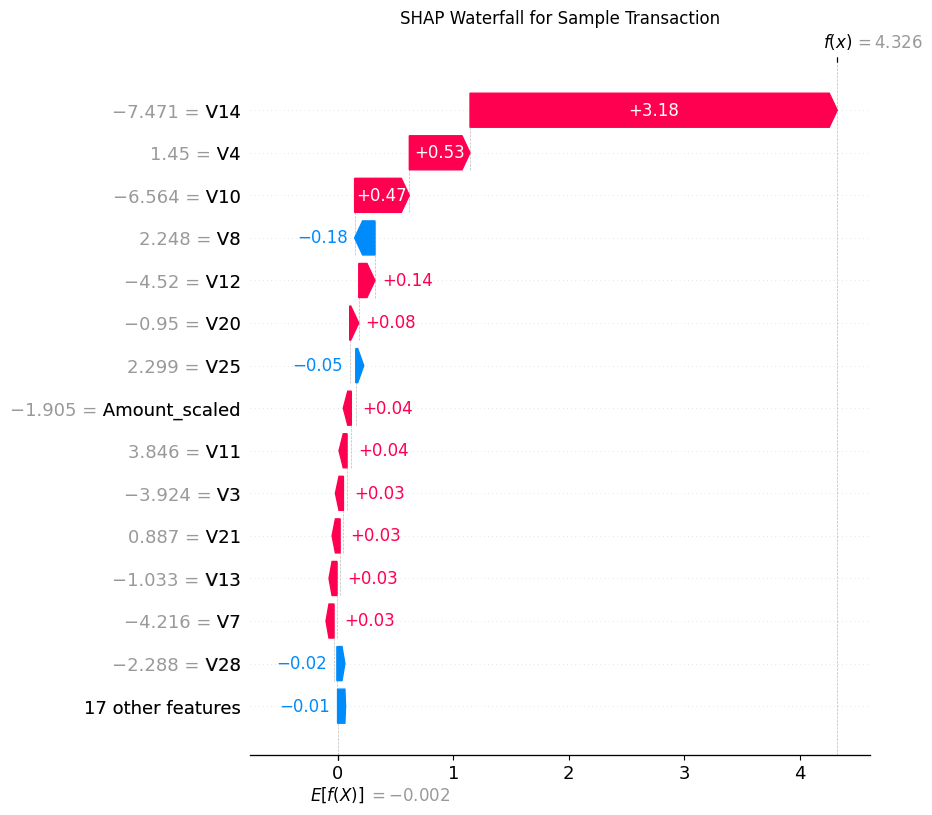

In [62]:
# waterfall plot
shap_explanation = shap.Explanation(
    values = shap_values[sample_idx],
    base_values = explainer.expected_value,
    data = X_val.iloc[sample_idx],
    feature_names = X_val.columns.tolist()
)

plt.figure(figsize=(10,6))
shap.plots.waterfall(shap_explanation, max_display=15, show = False)
plt.title('SHAP Waterfall for Sample Transaction')
plt.savefig('../data/processed/fig_shap_waterfall.png', dpi = 150, bbox_inches = 'tight')

plt.show()

##### **Notes:**

The waterfall plot above shows some really useful and interesting insight into the data. The red and blue arrows next to each feature indicates how much the feature pushed the transaction towards fraud (red arrow) or towards legitimate (blue arrow). So as above, the -7.471 of V14 heavily pushed this transaction towards fraud and the moderately high V4 also pushed the transaction towards fraud.

### 6. Save the Model

In [63]:
os.makedirs('../models', exist_ok=True)

In [64]:
nn_model.save('../models/fraud_nn_model.keras')
print('Keras NN Saved!')

Keras NN Saved!


In [65]:
with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print('XGBoost Saved!')

XGBoost Saved!


In [68]:
# model metadata:
model_metadata = {
    'nn_threshold': float(nn_best_thresh),
    'xgb_threshold': float(xgb_best_thresh),
    'deployed_model': 'keras_nn',
    'explainability_model': 'xgboost',
    'feature_count': int(X_train.shape[1]),
    'feature_names': X_train.columns.tolist(),
    'val_metrics': {
        'nn': {
            'precision': float(nn_results['precision']),
            'recall': float(nn_results['recall']),
            'f1': float(nn_results['f1']),
            'auc_pr': float(nn_results['auc_pr'])
        },
        'xgb': {
            'precision': float(xgb_results['precision']),
            'recall': float(xgb_results['recall']),
            'f1': float(xgb_results['f1']),
            'auc_pr': float(xgb_results['auc_pr'])
        }
    }

}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent = 4)

print('Model metadata saved!')

Model metadata saved!


In [69]:
# testing saved models to ensure clean saves

nn_saved = tf.keras.models.load_model('../models/fraud_nn_model.keras')

with open('../models/xgb_model.pkl', 'rb') as f:
    xgb_saved = pickle.load(f)

with open('../models/model_metadata.json', 'r') as f:
    meta_saved = json.load(f)


sample = X_val_nn[:1]

nn_score = nn_saved.predict(sample, verbose = 0).flatten()[0]
xgb_score = xgb_saved.predict_proba(X_val.iloc[:1])[:,1][0]

nn_thresh = meta_saved['nn_threshold']
xgb_thresh = meta_saved['xgb_threshold']

print('==== Testing Saved Models to Enusre Clean Saving ====')
print(f'NN Risk Score: {nn_score:.4f} | NN Threshold: {nn_thresh:.4f} | Sample Decision: {'Fraud' if nn_score >= nn_thresh else 'Legitimate'}')
print(f'XGBoost Risk Score: {xgb_score:.4f} | XGBoost Threshold: {xgb_thresh:.4f} | Sample Decision: {'Fraud' if xgb_score >= xgb_thresh else 'Legitimate'}')


==== Testing Saved Models to Enusre Clean Saving ====
NN Risk Score: 0.0000 | NN Threshold: 0.9728 | Sample Decision: Legitimate
XGBoost Risk Score: 0.0123 | XGBoost Threshold: 0.9852 | Sample Decision: Legitimate


##### **Notes:**

Both models saved and loaded cleanly! The NN Risk of 0.0000 is due to a few factors. The Neural Network is extremely confident in legitimate transactions, the sigmoid activation function on the final layer combined with it being a float is what will make these scores 0. Visually this looks like a possible error, but the model is actually just very confident.

---
##### Summary of Notebook

Being that this is an extremely important notebook in the processes of predicting fraud I want to highlight what actually took place here:

- Trained Models: XGBoost, Keras Neural Network
- Selected Model: Keras Neural Network (superior metrics)
- Explainability: XGBoost SHAP (Utilizing the TreeExplainer)
- Top Fraud Signal: Feature V14 (lower V14, higher probability of fraud)

All items were saved to the models folder

Keras NN Validation Results:
- Precision: .95
- Recall: .82
- F1 Score: .87
- PR-AUC: .85
---

Next notebook, '04_forecasting.ipynb'